In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import os.path as op

from specula.mmlib.analyse_data import get_sim_data
root_dir = '/raid1/mmenessini/calibration/FSOC'
result_dir = '/raid1/mmenessini/results/FSOC'

2026-08-07 17:10:46,939 [INFO]: [specula]: Cupy import successfull. Installed version is: 13.3.0
2026-08-07 17:10:47,074 [INFO]: [specula]: Default device is GPU number 0
2026-08-07 17:10:47,275 [INFO]: [specula]: Cupy import successfull. Installed version is: 13.3.0
2026-08-07 17:10:47,276 [INFO]: [specula]: Default device is GPU number 0


In [2]:
import matplotlib as mpl
from cycler import cycler

cmap = mpl.colormaps['hot'] # 1. Choose your colormap (e.g., 'hot', 'jet', 'turbo')
colors = cmap(np.linspace(0.1, 0.9, 7)) # 2. Extract a set of colors from it (e.g., 6 distinct colors across the map)
plt.rcParams['axes.prop_cycle'] = cycler(color=colors) # 3. Apply it to the default line cycle
plt.rcParams['image.cmap'] = 'hot' # 4. Change the default colormap for images/scatter plots
plt.rcParams.update({
    "text.usetex": True, # Use LaTeX to write all text
    "font.family": "serif", # Use a serif font
    "font.serif": ["Computer Modern Roman"] # Specifically use the classic LaTeX font
})
plt.rcParams['image.origin'] = 'lower'

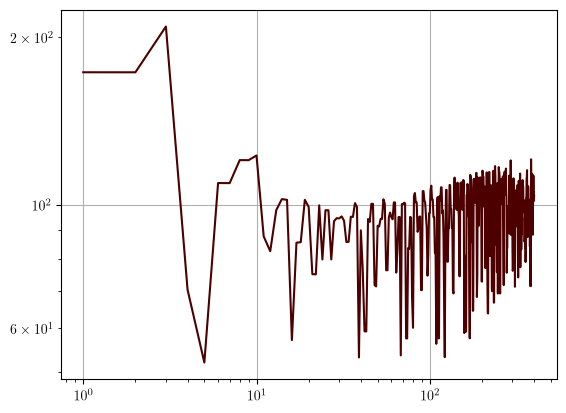

In [3]:
rec = fits.getdata(op.join(root_dir,'rec','pyr0.0_40x40_400modes_rec.fits'))

cov = np.diag(rec @ rec.T)
x = np.arange(len(cov))+1

plt.figure()
plt.loglog(x,cov)
plt.grid()

In [4]:
data = get_sim_data(result_dir,tn='20260807_150320')

raw_amps = data['uncorr_ef'][:,0,:,:]
raw_phases = data['uncorr_ef'][:,1,:,:]
amps = data['corr_ef'][:,0,:,:]
phases = data['corr_ef'][:,1,:,:]
dm_phase = data['dm_complex_shape'][:,1,:,:]

Using data directory: /raid1/mmenessini/results/FSOC/20260807_150320
key: dm_complex_shape type: <class 'numpy.ndarray'>
key: uncorr_ef type: <class 'numpy.ndarray'>
key: corr_ef type: <class 'numpy.ndarray'>
key: frames type: <class 'numpy.ndarray'>


Text(0.5, 1.0, 'Mode 80\n$\\Delta$ phase (uncorrected), RMS=3.5nm')

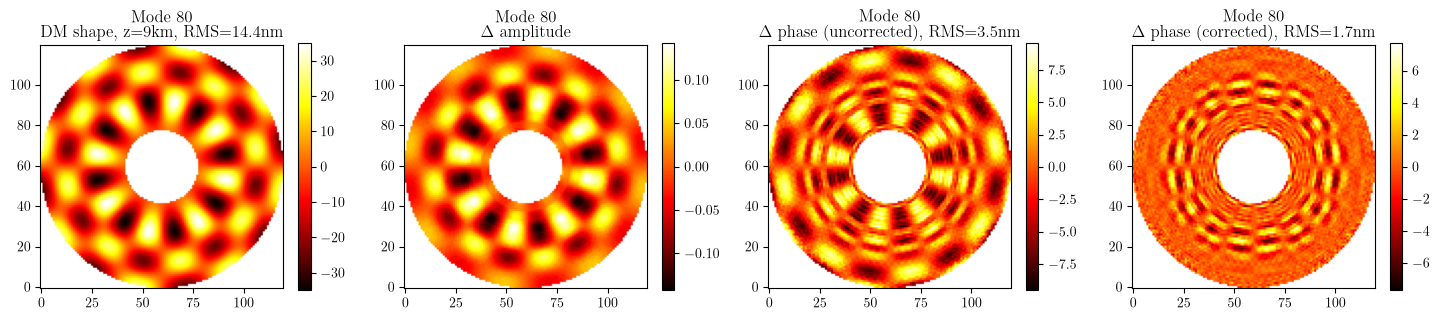

In [9]:
pymask = np.sum(abs(amps),axis=0) == 0

idx = 80

plt.figure(figsize=(18,4))
plt.subplot(1,4,1)
dm_dphi = dm_phase[idx*2+1]-dm_phase[idx*2]
plt.imshow(np.ma.masked_array(dm_dphi,mask=pymask))
plt.colorbar(shrink=0.8)
plt.title(f'Mode {idx}\nDM shape, z=9km, RMS={np.sqrt(np.mean(dm_dphi[~pymask]**2)):.1f}nm')
plt.subplot(1,4,4)
dphase = phases[idx*2+1]-phases[idx*2]
plt.imshow(np.ma.masked_array(dphase,mask=pymask))
plt.colorbar(shrink=0.8)
plt.title(f'Mode {idx}\n'+r'$\Delta$ phase (corrected)'+f', RMS={np.sqrt(np.mean(dphase[~pymask]**2)):.1f}nm')
plt.subplot(1,4,2)
damps = amps[idx*2+1]-amps[idx*2]
plt.imshow(np.ma.masked_array(damps,mask=pymask))
plt.colorbar(shrink=0.8)
plt.title(f'Mode {idx}\n'+r'$\Delta$ amplitude')
plt.subplot(1,4,3)
raw_dphase = raw_phases[idx*2+1]-raw_phases[idx*2]
plt.imshow(np.ma.masked_array(raw_dphase,mask=pymask))
plt.colorbar(shrink=0.8)
plt.title(f'Mode {idx}\n'+r'$\Delta$ phase (uncorrected)'+f', RMS={np.sqrt(np.mean(raw_dphase[~pymask]**2)):.1f}nm')

Text(0, 0.5, '$h [km]$')

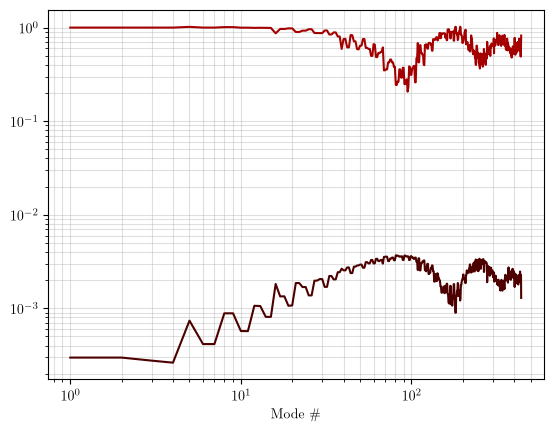

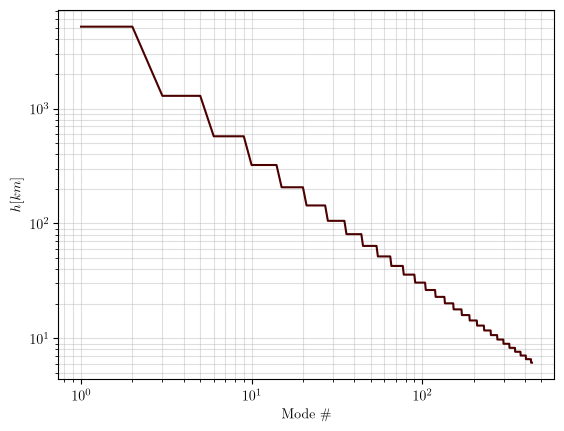

In [6]:
from specula.mmlib.utils import radial_order

Nmodes = 440
wavelength = 1550*1e-9
D = 1.0
n = radial_order(np.arange(Nmodes))
d = 2*D/n
talbot_length = 2*d**2/wavelength

amp_rms = np.zeros(Nmodes)
cmd_rms = np.zeros(Nmodes)
phi_rms = np.zeros(Nmodes)
for i in range(Nmodes):
    dphase = phases[i*2+1]-phases[i*2]
    dphase = raw_phases[i*2+1]-raw_phases[i*2]
    damps = amps[i*2+1]-amps[i*2]
    dm_dphi = dm_phase[i*2+1]-dm_phase[i*2]
    phi_rms[i] = np.sqrt(np.mean(dphase[~pymask]**2))
    amp_rms[i] = np.sqrt(np.mean(damps[~pymask]**2))
    cmd_rms[i] = np.sqrt(np.mean(dm_dphi[~pymask]**2))
                         

plt.figure()
plt.loglog(np.arange(Nmodes)+1,amp_rms/cmd_rms)
plt.loglog(np.arange(Nmodes)+1,phi_rms/cmd_rms)
plt.grid(which='both',alpha=0.4)
plt.xlabel('Mode \#')

plt.figure()
plt.loglog(np.arange(Nmodes)+1,talbot_length*1e-3)
plt.grid(which='both',alpha=0.4)
plt.xlabel('Mode \#')
plt.ylabel(r'$h [km]$')

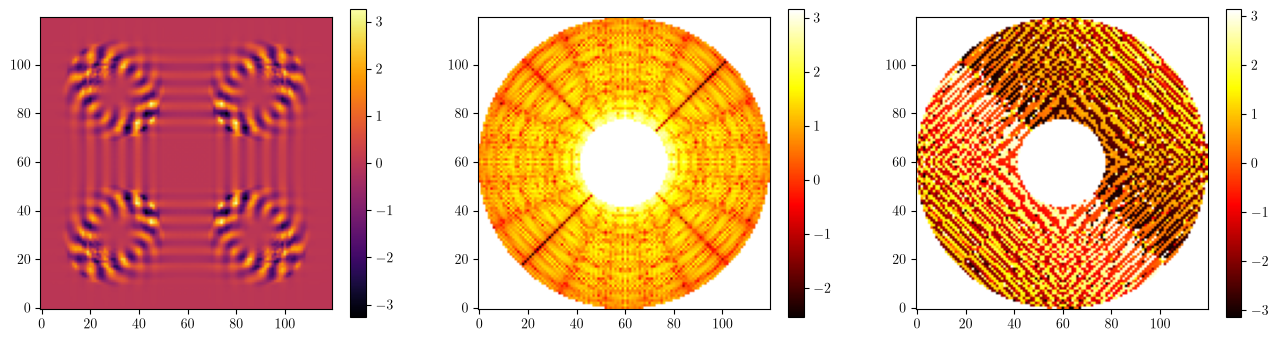

In [7]:


frames = data['frames']
signal = frames[idx*2+1]-frames[idx*2]
oversampling = 1
L = signal.shape[0]
s = (oversampling-1)*L//2
pad_signal = np.pad(signal,pad_width=s,mode='constant',constant_values=0.0)
sfft = np.fft.ifftshift(np.fft.fft2(np.fft.fftshift(pad_signal)))

plt.figure(figsize=(16,4))
plt.subplot(1,3,1)
plt.imshow(signal,origin='lower',cmap='inferno')
plt.colorbar()
plt.subplot(1,3,2)
plt.imshow(np.ma.masked_array(np.log10(np.abs(sfft)),mask=pymask)) 
plt.colorbar()
plt.subplot(1,3,3)
plt.imshow(np.ma.masked_array(np.angle(sfft),mask=pymask))
plt.colorbar()

In [8]:
# init = 400
# atmo_res_rms = np.sqrt(np.mean(atmo_res[init:]**2,axis=0))
# dm_res_rms = np.sqrt(np.mean(dm_res[init:]**2,axis=0))

# x = np.arange(dm_res.shape[1])+1

# plt.figure()
# plt.loglog(x,atmo_res_rms)
# plt.loglog(x,dm_res_rms)
# plt.grid(alpha=0.4,which='both')